Total CTs: 347


Processing CTs: 100%|██████████| 347/347 [27:55<00:00,  4.83s/it] 



Saved: normal_lung_voxels_with_meta.npz
Total CTs saved: 347

Example CT:
CT name: train_12342_a_1
Voxel shape: (647180,)


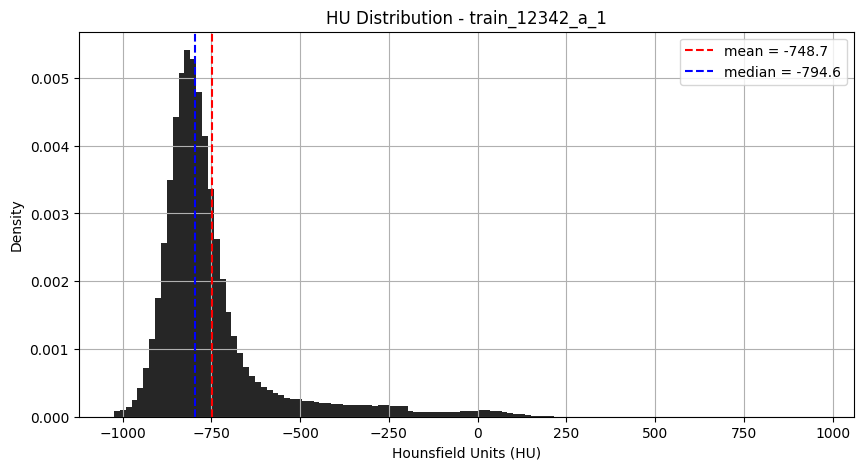

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage.segmentation import clear_border
from tqdm import tqdm

from lc_ksvd.data_loader import LabelRegistry, MetadataRegistry, load_volume, resample_volume
from lc_ksvd.config import HU_MIN, HU_MAX


# -------------------------------------------------------
# Lung mask
# -------------------------------------------------------
def build_lung_mask(vol):
    mask = (vol >= HU_MIN) & (vol <= HU_MAX)

    mask_clear = np.zeros_like(mask, dtype=bool)

    for z in range(mask.shape[2]):
        mask_clear[:, :, z] = clear_border(mask[:, :, z])

    labels, num = ndimage.label(mask_clear)

    if num > 0:
        sizes = ndimage.sum(mask_clear, labels, range(1, num + 1))

        if len(sizes) >= 2:
            largest_two = np.argsort(sizes)[-2:] + 1
            lung_mask = np.isin(labels, largest_two)
        else:
            lung_mask = labels > 0
    else:
        lung_mask = mask_clear

    structure = ndimage.generate_binary_structure(3, 2)
    lung_mask = ndimage.binary_closing(lung_mask, structure=structure, iterations=2)
    lung_mask = ndimage.binary_fill_holes(lung_mask)

    return lung_mask


# -------------------------------------------------------
# Init
# -------------------------------------------------------
metadata = MetadataRegistry(split=None)
labels = LabelRegistry(metadata, split=None)

normal_volume_names = labels.get_normal_volume_names()

print("Total CTs:", len(normal_volume_names))


# -------------------------------------------------------
# Store per CT
# -------------------------------------------------------
dataset = []


# -------------------------------------------------------
# Process CTs
# -------------------------------------------------------
for volume_name in tqdm(normal_volume_names, desc="Processing CTs"):

    try:
        vol_hu, spacing = load_volume(volume_name)
        vol_rs = resample_volume(vol_hu, spacing)

        lung_mask = build_lung_mask(vol_rs)
        lung_voxels = vol_rs[lung_mask].astype(np.float32)

        if lung_voxels.size == 0:
            continue

        dataset.append({
            "ct_name": volume_name,
            "voxels": lung_voxels
        })

    except Exception as e:
        print(f"Skipped {volume_name}: {e}")


# -------------------------------------------------------
# Save NPZ (with metadata)
# -------------------------------------------------------
output_file = "normal_lung_voxels_with_meta.npz"

np.savez_compressed(
    output_file,
    data=np.array(dataset, dtype=object)
)

print("\nSaved:", output_file)
print("Total CTs saved:", len(dataset))


# -------------------------------------------------------
# Load back example (test)
# -------------------------------------------------------
loaded = np.load(output_file, allow_pickle=True)
records = loaded["data"]

print("\nExample CT:")
print("CT name:", records[0]["ct_name"])
print("Voxel shape:", records[0]["voxels"].shape)


# -------------------------------------------------------
# Plot one CT HU distribution
# -------------------------------------------------------
voxels = records[0]["voxels"]

plt.figure(figsize=(10, 5))

plt.hist(voxels, bins=120, density=True, alpha=0.85, color="black")

plt.axvline(voxels.mean(), color="red", linestyle="--",
            label=f"mean = {voxels.mean():.1f}")

plt.axvline(np.median(voxels), color="blue", linestyle="--",
            label=f"median = {np.median(voxels):.1f}")

plt.title(f"HU Distribution - {records[0]['ct_name']}")
plt.xlabel("Hounsfield Units (HU)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.show()

In [6]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage.segmentation import clear_border
from tqdm import tqdm

from lc_ksvd.config import HU_MIN, HU_MAX
from lc_ksvd.data_loader import LabelRegistry, MetadataRegistry, load_volume, resample_volume

print(">>> SCRIPT STARTED")
# -------------------------------------------------------
# Lung mask (your method)
# -------------------------------------------------------
def build_lung_mask(vol):
    mask = (vol >= HU_MIN) & (vol <= HU_MAX)

    mask_clear = np.zeros_like(mask, dtype=bool)
    for z in range(mask.shape[2]):
        mask_clear[:, :, z] = clear_border(mask[:, :, z])

    labels, num = ndimage.label(mask_clear)

    if num > 0:
        sizes = ndimage.sum(mask_clear, labels, range(1, num + 1))

        if len(sizes) >= 2:
            largest_two = np.argsort(sizes)[-2:] + 1
            lung_mask = np.isin(labels, largest_two)
        else:
            lung_mask = labels > 0
    else:
        lung_mask = mask_clear

    structure = ndimage.generate_binary_structure(3, 2)
    lung_mask = ndimage.binary_closing(lung_mask, structure=structure, iterations=2)
    lung_mask = ndimage.binary_fill_holes(lung_mask)

    return lung_mask


# -------------------------------------------------------
# Init
# -------------------------------------------------------
metadata = MetadataRegistry(split=None)
labels = LabelRegistry(metadata, split=None)

abnormalities = ["2b", "2c", "2d"]

output_dir = Path("/home/chest_ct/code/models/lc-ksvd/eda_outputs/npz_voxels")
output_dir.mkdir(parents=True, exist_ok=True)

bins = np.arange(-1000, 251, 10)


# -------------------------------------------------------
# MAIN LOOP
# -------------------------------------------------------
for category in abnormalities:

    print(f"\nProcessing category: {category}")

    volume_names = labels.get_positive_volume_names(category)

    all_lung_voxels = []

    # ---------------------------
    # Collect voxels
    # ---------------------------
    for volume_name in tqdm(volume_names, desc=f"Processing {category}", unit="vol"):

        try:
            vol_hu, spacing = load_volume(volume_name)
            vol_rs = resample_volume(vol_hu, spacing)

            lung_mask = build_lung_mask(vol_rs)
            lung_voxels = vol_rs[lung_mask].astype(np.float32)

            if lung_voxels.size > 0:
                all_lung_voxels.append(lung_voxels)

        except Exception as e:
            print(f"Skipped {volume_name}: {e}")

    if not all_lung_voxels:
        print(f"No data for {category}")
        continue

    # ---------------------------
    # Merge voxels
    # ---------------------------
    all_lung_voxels = np.concatenate(all_lung_voxels).astype(np.float32)

    print(f"{category}: total voxels = {all_lung_voxels.size:,}")

    # ---------------------------
    # Save npz
    # ---------------------------
    save_path = output_dir / f"{category}_lung_voxels.npz"

    np.savez_compressed(save_path, voxels=all_lung_voxels)

    print(f"Saved: {save_path}")

    # ---------------------------
    # Plot distribution
    # ---------------------------
    plt.figure(figsize=(10, 5))

    hist, _ = np.histogram(all_lung_voxels, bins=bins, density=True)

    plt.plot(bins[:-1], hist, linewidth=2, label=f"{category}")

    plt.axvline(all_lung_voxels.mean(), color="red", linestyle="--",
                label=f"mean = {all_lung_voxels.mean():.1f}")

    plt.axvline(np.median(all_lung_voxels), color="blue", linestyle="--",
                label=f"median = {np.median(all_lung_voxels):.1f}")

    plt.title(f"HU Distribution (Lung Voxels) - {category}")
    plt.xlabel("Hounsfield Units (HU)")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()

>>> SCRIPT STARTED

Processing category: 2b


Processing 2b: 0vol [00:00, ?vol/s]


No data for 2b

Processing category: 2c


Processing 2c:   3%|▎         | 33/1176 [01:31<52:50,  2.77s/vol]


KeyboardInterrupt: 

Total CT scans: 347

===== GLOBAL HU STATISTICS =====
Total voxels: 512,300,757
Min HU: -29001.77
Mean HU: -789.81
Median HU: -846.92
Max HU: 29808.06

Percentiles:
P1: -1010.27
P5: -954.96
P25: -890.66
P50: -846.92
P75: -769.66
P95: -350.17
P99: -28.53

===== PER-CT SUMMARY (first 5) =====

CT: train_12342_a_1
  Voxels: 647,180
  Min/Mean/Median/Max: -1024.0 / -748.7 / -794.6 / 960.1

CT: train_10990_a_1
  Voxels: 1,798,687
  Min/Mean/Median/Max: -1024.0 / -841.5 / -888.7 / 3071.0

CT: train_9664_a_1
  Voxels: 1,203,990
  Min/Mean/Median/Max: -1024.0 / -736.4 / -788.2 / 628.7

CT: train_2863_a_1
  Voxels: 1,340,260
  Min/Mean/Median/Max: -1023.9 / -763.3 / -819.7 / 320.8

CT: train_5462_a_2
  Voxels: 3,010,804
  Min/Mean/Median/Max: -1024.0 / -848.0 / -893.5 / 1177.1


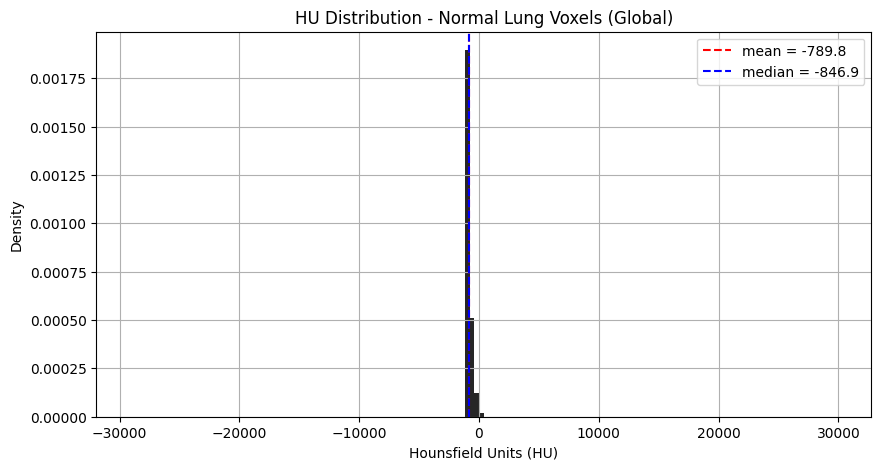

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------
# Load dataset
# -------------------------------------------------------
file_path = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/normal_lung_voxels_with_meta.npz"

data = np.load(file_path, allow_pickle=True)
records = data["data"]

print("Total CT scans:", len(records))


# -------------------------------------------------------
# Collect all voxels (global distribution)
# -------------------------------------------------------
all_voxels = np.concatenate([r["voxels"] for r in records]).astype(np.float32)

print("\n===== GLOBAL HU STATISTICS =====")
print(f"Total voxels: {all_voxels.size:,}")
print(f"Min HU: {all_voxels.min():.2f}")
print(f"Mean HU: {all_voxels.mean():.2f}")
print(f"Median HU: {np.median(all_voxels):.2f}")
print(f"Max HU: {all_voxels.max():.2f}")

print("\nPercentiles:")
for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f"P{p}: {np.percentile(all_voxels, p):.2f}")


# -------------------------------------------------------
# Per-CT statistics
# -------------------------------------------------------
print("\n===== PER-CT SUMMARY (first 5) =====")

for r in records[:5]:
    v = r["voxels"]
    print(f"\nCT: {r['ct_name']}")
    print(f"  Voxels: {v.size:,}")
    print(f"  Min/Mean/Median/Max: "
          f"{v.min():.1f} / {v.mean():.1f} / {np.median(v):.1f} / {v.max():.1f}")


# -------------------------------------------------------
# Histogram (global)
# -------------------------------------------------------
plt.figure(figsize=(10, 5))

plt.hist(all_voxels, bins=150, density=True, alpha=0.85, color="black")

plt.axvline(all_voxels.mean(), color="red", linestyle="--",
            label=f"mean = {all_voxels.mean():.1f}")

plt.axvline(np.median(all_voxels), color="blue", linestyle="--",
            label=f"median = {np.median(all_voxels):.1f}")

plt.title("HU Distribution - Normal Lung Voxels (Global)")
plt.xlabel("Hounsfield Units (HU)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.show()

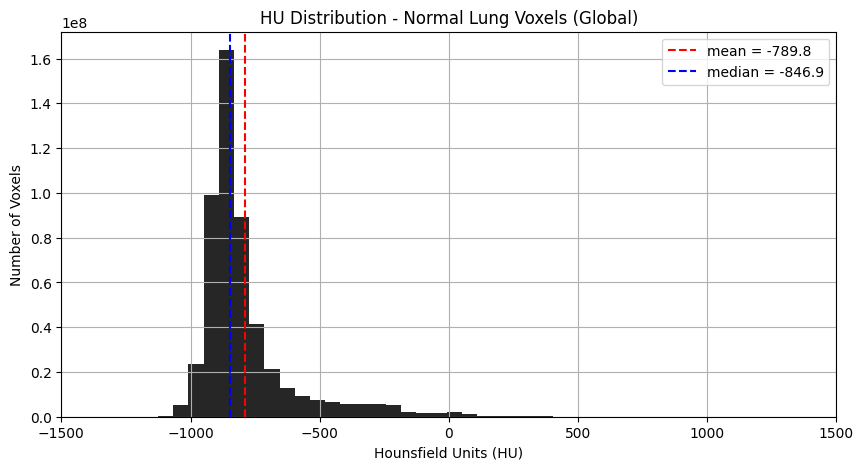

In [16]:
# -------------------------------------------------------
# Histogram (global - voxel counts)
# -------------------------------------------------------
plt.figure(figsize=(10, 5))

plt.hist(all_voxels, bins=1000, alpha=0.85, color="black")

plt.axvline(all_voxels.mean(), color="red", linestyle="--",
            label=f"mean = {all_voxels.mean():.1f}")

plt.axvline(np.median(all_voxels), color="blue", linestyle="--",
            label=f"median = {np.median(all_voxels):.1f}")

plt.title("HU Distribution - Normal Lung Voxels (Global)")
plt.xlabel("Hounsfield Units (HU)")
plt.ylabel("Number of Voxels")   # changed

plt.xlim(-1500,1500)

plt.legend()
plt.grid(True)

plt.show()

In [8]:
import numpy as np

file_path = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/normal_lung_voxels_with_meta.npz"

data = np.load(file_path, allow_pickle=True)
records = data["data"]

bad_cts = []

# -------------------------------------------------------
# Scan per CT
# -------------------------------------------------------
for r in records:

    voxels = r["voxels"]

    min_v = float(voxels.min())
    max_v = float(voxels.max())

    # threshold for abnormal CT intensity
    if min_v < -1024 or max_v > 3071:
        bad_cts.append({
            "ct_name": r["ct_name"],
            "min": min_v,
            "max": max_v,
            "voxels": voxels.size
        })


# -------------------------------------------------------
# Sort by worst extreme value
# -------------------------------------------------------
bad_cts_sorted = sorted(
    bad_cts,
    key=lambda x: max(abs(x["min"]), abs(x["max"])),
    reverse=True
)


# -------------------------------------------------------
# Print results
# -------------------------------------------------------
print("===== EXTREME CT SCANS =====")
print(f"Total bad CTs: {len(bad_cts_sorted)}\n")

for c in bad_cts_sorted[:20]:
    print(f"CT: {c['ct_name']}")
    print(f"  Min HU: {c['min']:.1f}")
    print(f"  Max HU: {c['max']:.1f}")
    print(f"  Voxels: {c['voxels']:,}")
    print("-" * 40)

===== EXTREME CT SCANS =====
Total bad CTs: 73

CT: train_136_a_2
  Min HU: -29001.8
  Max HU: 29808.1
  Voxels: 1,550,125
----------------------------------------
CT: train_9186_a_2
  Min HU: -4070.3
  Max HU: 28247.3
  Voxels: 1,153,184
----------------------------------------
CT: train_13441_a_2
  Min HU: -1024.0
  Max HU: 27554.0
  Voxels: 1,683,685
----------------------------------------
CT: train_12958_a_2
  Min HU: -11584.0
  Max HU: 26201.3
  Voxels: 1,385,587
----------------------------------------
CT: train_18518_a_2
  Min HU: -4135.8
  Max HU: 26154.6
  Voxels: 1,614,320
----------------------------------------
CT: train_19847_a_2
  Min HU: -4101.8
  Max HU: 22922.2
  Voxels: 1,299,852
----------------------------------------
CT: train_4255_a_2
  Min HU: -1024.0
  Max HU: 22365.3
  Voxels: 1,542,150
----------------------------------------
CT: train_5977_a_2
  Min HU: -2472.4
  Max HU: 19390.8
  Voxels: 737,412
----------------------------------------
CT: train_19464_a_2
 